Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defining parameters

In [ ]:


n_users = 35        # secondary users
n_primary = 8       # primary channels
n_channels = 40     # available spectrum bands

noise = 0.1         # noise for SINR

PS_penalty = 75     # penalty for primary-econdary user channel collision
SS_penalty = 25     # penalty for secondary-secondary user channel collision

N=200               # particles
S=n_channels-1      # search space [0, n_channels-1]
D=n_users           # dimensions = number of users
n_iter = 600        # number of updates of positions

a=0.9
b=1.496
b_hat=1.496
c=0.5

beta_start = 1
beta_end = 0.5


Getting SINR from random

In [3]:
# Simulate channel gains randomly (in reality this comes from pathloss model)
# SINR[i][j] = signal quality if user i uses channel j
np.random.seed(67)
channel_gain = np.random.uniform(0.1, 1.0, (n_users, n_channels))     # to get SINR which gets throughput
SINR = channel_gain / noise                                           # simplified, no inter-user interference yet



Setting up Primary Users

In [4]:
# Primary user occupancy: PU[j] = 1 means channel j is occupied by primary user

PU_occupied = np.zeros(n_channels, dtype=int)
PU_occupied[np.random.choice(n_channels, n_primary, replace=False)] = 1

Fitness function which gets the throughput using SINR and adds penalty

In [5]:
def fitness(x, PS_penalty=PS_penalty, SS_penalty=SS_penalty):
    channels = np.clip(np.round(x).astype(int), 0, n_channels - 1)
    pu_mask = PU_occupied[channels]                          # 1 where PU is present
    sinr_vals = SINR[np.arange(n_users), channels]          # SINR for each user's channel
    
    throughput = np.sum(np.log2(1 + sinr_vals) * (1 - pu_mask))
    ps_penalty = np.sum(pu_mask) * PS_penalty
    
    counts = np.bincount(channels, minlength=n_channels)
    ss_pen = np.sum(np.maximum(counts - 1, 0)) * SS_penalty
    
    return -throughput + ps_penalty + ss_pen

PSO algorithm

In [6]:
def dpso(f, D, N, S, n_iter, a, b, b_hat, c, see):
    np.random.seed(see)
    x = np.random.uniform(0, S, size=(N, D))                 # setting up the initial positions of the N number of particles
    v = np.random.normal(size=(N, D))                        # setting up the initial velocities
    p = x.copy()                                             # best particle position
    fp = np.array([f(p[i]) for i in range(N)])               # throughput of all particles
    p_hat = x[np.argmin(fp)].copy()                          # global best position
    fp_hat = f(p_hat)                                        # throughput of global best position
    fp_hat_his = []

    for i in range (n_iter):
        fp_hat_his.append(float(fp_hat))
        #if i%(n_iter//10)== 0:                               # to show progress
            #print(f"progress {(i/n_iter)*100:.0f}%")
            #pass
            

        r,r_hat = np.random.uniform(0, 1, (2,N, D))          # setting up random parameters

        v = a*v + b*r*(p-x) + b_hat*r_hat*(p_hat-x)          # updating velocities as vector sum of the directions of initial velocity, local minima, local maxima
        x = x + c*v                                          # updating position according to velocities
        x = np.clip(x, 0, S)                                 # to limit the range within the subspace

        for n in range(N):                                   # calculation for each particle

            xn = x[n]                                        # getting position of that particle           
            fxn = f(xn)                                      # current throughput of that particle
            fpn = fp[n]                                      # best throughput of that particle

            if fxn < fpn:                                    # if current throughput of that particle is better the previous ones, update
                p[n] = xn.copy()
                fp[n] = fxn

                if fxn < fp_hat:                             # if the current througput is the global best throughput, update
                    p_hat = xn.copy()
                    fp_hat = fxn
    
    # print("progress 100%")
    return p_hat,fp_hat_his                                  # "coordinates", ie channel allocation of global best throughput

        



Calling PSO 

In [7]:
n_seeds = 100
n_parameter = 800

results = np.empty((n_seeds, n_parameter//10))
for s in range(n_seeds):
    print("seed", s)
    for ss_idx, SS in enumerate(range(0,n_parameter,10)):
        result, history = dpso(fitness, D, N, S, SS+1, a, b, b_hat, c,s)
        C_best_assignment = np.clip(np.round(result).astype(int), 0, n_channels-1)
        C_throughput = 0
        for user in range(n_users):
            ch = C_best_assignment[user]
            if not PU_occupied[ch]:
                C_throughput += np.log2(1 + SINR[user, ch])
        results[s, ss_idx] = C_throughput   
avg_throughput = np.mean(results, axis=0)





seed 0
seed 1
seed 2
seed 3
seed 4
seed 5
seed 6
seed 7
seed 8
seed 9
seed 10
seed 11
seed 12
seed 13
seed 14
seed 15
seed 16
seed 17
seed 18
seed 19
seed 20
seed 21
seed 22
seed 23
seed 24
seed 25
seed 26
seed 27
seed 28
seed 29
seed 30
seed 31
seed 32
seed 33
seed 34
seed 35
seed 36
seed 37
seed 38
seed 39
seed 40
seed 41
seed 42
seed 43
seed 44
seed 45
seed 46
seed 47
seed 48
seed 49
seed 50
seed 51
seed 52
seed 53
seed 54
seed 55
seed 56
seed 57
seed 58
seed 59
seed 60
seed 61
seed 62
seed 63
seed 64
seed 65
seed 66
seed 67
seed 68
seed 69
seed 70
seed 71
seed 72
seed 73
seed 74
seed 75
seed 76
seed 77
seed 78
seed 79
seed 80
seed 81
seed 82
seed 83
seed 84
seed 85
seed 86
seed 87
seed 88
seed 89
seed 90
seed 91
seed 92
seed 93
seed 94
seed 95
seed 96
seed 97
seed 98
seed 99


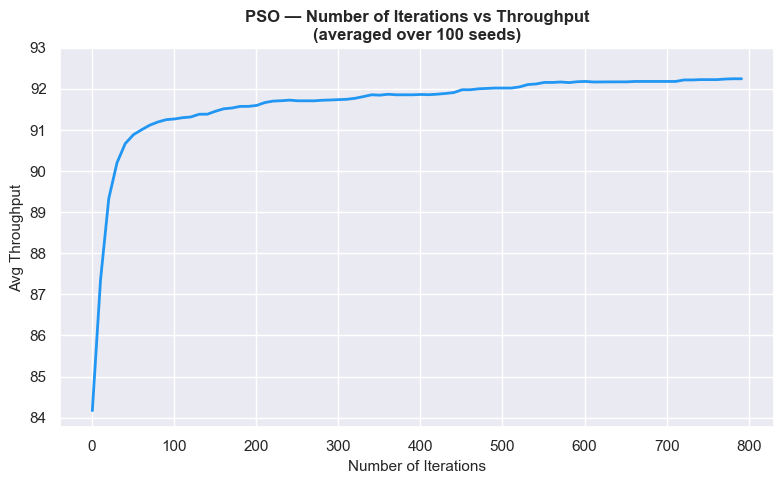

In [11]:
from pathlib import Path

sns.set_theme(style="darkgrid")

# actual n_iter values used: SS+1 for SS in range(0, n_parameter, 10)
iter_values = list(range(1, 801, 10))   # SS+1 for SS in range(0, 800, 10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iter_values, avg_throughput, color="#2196F3", linewidth=2)

ax.set_xlabel("Number of Iterations", fontsize=11)
ax.set_ylabel("Avg Throughput", fontsize=11)
ax.set_title("PSO — Number of Iterations vs Throughput\n(averaged over 100 seeds)",fontsize=12, fontweight="bold")

ymin = np.floor(min(avg_throughput))
ymax = np.ceil(max(avg_throughput))
ax.set_yticks(np.arange(ymin, ymax + 1, 1))

plt.tight_layout()
plt.savefig(
    Path.home() / "OneDrive" / "Desktop" / "pso_iter_sweep.png",
    dpi=400,
    bbox_inches="tight"
)
plt.show()

In [ ]:
np.save(Path.home() / "OneDrive" / "Desktop" / "Number_of_iterations.npy", iter_values)
np.save(Path.home() / "OneDrive" / "Desktop" / "avg_throughput_iter.npy", avg_throughput)


array([84.16932603, 87.35735344, 89.33132981, 90.20139353, 90.66850949,
       90.88644758, 91.00683307, 91.11896414, 91.19699566, 91.25230963,
       91.26893898, 91.30028156, 91.3184812 , 91.38425165, 91.38521342,
       91.45771613, 91.51702386, 91.53594943, 91.57502756, 91.57579619,
       91.5985835 , 91.6686516 , 91.70384187, 91.7130885 , 91.72713788,
       91.7108343 , 91.7108343 , 91.7108343 , 91.72480197, 91.73094779,
       91.7394553 , 91.74811701, 91.77324247, 91.81410286, 91.85725868,
       91.84823683, 91.86964646, 91.85722822, 91.85722822, 91.85722822,
       91.86488844, 91.85970596, 91.87222492, 91.88953124, 91.91185467,
       91.98010938, 91.98010938, 92.00304796, 92.01237834, 92.02152362,
       92.02152362, 92.02152362, 92.05002121, 92.10645732, 92.12013606,
       92.15800853, 92.15800853, 92.16862288, 92.15376192, 92.17526497,
       92.18228915, 92.16884547, 92.17041655, 92.17197712, 92.17197712,
       92.17207044, 92.18188175, 92.18188175, 92.18188175, 92.18

QPSO algorithm

In [ ]:
def dqpso(f, D, N, S, n_iter, beta_start, beta_end):

    x = np.random.uniform(0, S, size=(N, D))                            # setting up the initial positions of the N number of particles
    p = x.copy()                                                        # best particle position
    fp = np.array([f(p[i]) for i in range(N)])                          # throughput of all particles
    p_hat = x[np.argmin(fp)].copy()                                     # global best position
    fp_hat = f(p_hat)                                                   # throughput of global best position


    for i in range(n_iter):

        if i%(n_iter//10)== 0:                                          # to show progress
            print(f"progress {(i/n_iter)*100:.0f}%")
        
        
        beta = beta_start - (beta_start - beta_end) * i / n_iter        # Beta decreases linearly from beta_start to beta_end

        mbest = np.mean(p, axis=0)                                      # Mean best position ie average of all personal bests

        phi = np.random.uniform(0,1, (N,D))                             
        p_local = phi * p + (1 - phi) * p_hat                           # local attractor for each particle (works like velocity or inertia)

        u = np.random.uniform(1e-12, 1, (N,D))                           
        sign = 2 * np.random.randint(0, 2, size=(N,D)) - 1
        x = p_local + sign * beta * np.abs(mbest - x) * np.log(1/u)     # calculates the next value of x
        x = np.clip(x, 0, S)                                            # to limit the range within the subspace


        for n in range(N):                                              # calculation for each particle

            xn = x[n]                                                   # getting position of that particle           
            fxn = f(xn)                                                 # current throughput of that particle
            fpn = fp[n]                                                 # best throughput of that particle

            if fxn < fpn:                                               # if current throughput of that particle is better the previous ones, update
                p[n] = xn.copy()
                fp[n] = fxn

                if fxn < fp_hat:                                        # if the current througput is the global best throughput, update
                    p_hat = xn.copy()
                    fp_hat = fxn
    
    print("progress 100%")
    return p_hat                                                        # "coordinates", ie channel allocation of global best throughput

            

    

Calling QPSO

In [ ]:
"""
result_qpso = dqpso(fitness, D, N, S, n_iter, beta_start, beta_end)

Q_best_assignment = np.clip(np.round(result_qpso).astype(int), 0, n_channels-1)

Q_throughput = 0
for user in range(n_users):
    ch = Q_best_assignment[user]
    if not PU_occupied[ch]:
        Q_throughput += np.log2(1 + SINR[user, ch])
"""



'\nresult_qpso = dqpso(fitness, D, N, S, n_iter, beta_start, beta_end)\n\nQ_best_assignment = np.clip(np.round(result_qpso).astype(int), 0, n_channels-1)\n\nQ_throughput = 0\nfor user in range(n_users):\n    ch = Q_best_assignment[user]\n    if not PU_occupied[ch]:\n        Q_throughput += np.log2(1 + SINR[user, ch])\n'

In [ ]:
'''
print("Classical Particle Swarm Optimization\n")
print("Channel assignment:", C_best_assignment)
print("Throughput:", C_throughput)

print("\n\nQuantum Particle Swarm Optimization \n")
print("Channel assignment:", Q_best_assignment)
print("Throughput:", Q_throughput)
'''

'\nprint("Classical Particle Swarm Optimization\n")\nprint("Channel assignment:", C_best_assignment)\nprint("Throughput:", C_throughput)\n\nprint("\n\nQuantum Particle Swarm Optimization \n")\nprint("Channel assignment:", Q_best_assignment)\nprint("Throughput:", Q_throughput)\n'